## The model training

### This Notebook aims to create a machine learning model and train it using the engineered data

In [1357]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, root_mean_squared_log_error
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder

### 3.1 Load the data

In [1358]:
train_df = pd.read_csv('train_engineered_v2.csv')
test_df = pd.read_csv('test_engineered_v2.csv')

In [1359]:
train_df.head()

,UniqueID,next_3m_txn_count,TransactionAmount_sum,TransactionAmount_mean,TransactionAmount_median,TransactionAmount_std,TransactionAmount_count,TransactionAmount_max,TransactionAmount_min,StatementBalance_mean,...,NetInterestIncome_mean,NetInterestIncome_std,NetInterestRevenue_sum,NetInterestRevenue_mean,Product_nunique,Gender,IncomeCategory,AnnualGrossIncome,OccupationCategory,CustomerStatus
0,00093e2d-9e1e-4061-ad27-a79b8ff9e165,129,-894563.40,-572.703841,-925.520,88833.409077,1562,1000000.00,-1000000.00,79175.340800,...,1304.165333,2414.125438,10647.86,236.619111,3.0,M,High Income,2244579.16,Management / Executive,Active Customer
1,0011d60f-a4e2-4333-81fc-2d557a82109b,16,-2000656.68,-7970.743745,-301.590,132902.058472,251,1000000.00,-1000000.00,463595.304900,...,-1775.770476,3450.277593,20482.99,975.380476,1.0,M,High Income,1251211.80,Management / Executive,Active Customer
2,0016f1e2-64c1-4c65-a668-1dc6bf3b5875,117,-127.16,-2.890000,-2.020,3.039344,44,0.00,-8.05,279.836136,...,-2.015238,0.428388,105.33,5.015714,1.0,M,Middle Income,344297.42,Other / Unclassified,Active Customer
3,001aa3c5-632d-435e-a421-cc3615ccef4d,70,87729.20,258.027059,-895.765,89647.208240,340,1000000.00,-698552.99,81728.208706,...,-433.280976,852.424778,6773.93,165.217805,2.0,F,Very High Income,1846455.79,Management / Executive,Active Customer
4,00298c6f-4f9d-4f28-b72c-ad0e56e9eb84,393,44110.45,20.650960,-143.645,9755.953589,2136,122286.62,-38055.67,155872.668043,...,-463.207273,859.880422,6383.57,290.162273,2.0,M,Very High Income,2176785.64,Management / Executive,Active Customer


In [1360]:
print(train_df.shape)
print(test_df.shape)

(8360, 30)
(3584, 29)


In [1361]:
categorical_cols = train_df.select_dtypes(include= 'str').columns

print(categorical_cols)

Index(['UniqueID', 'Gender', 'IncomeCategory', 'OccupationCategory',
       'CustomerStatus'],
      dtype='str')


### 3.2. Encoding the categorical into numerical to ensure the model processes correctly to these columns

In [1362]:
# numerical encode
for col in categorical_cols:
    if col != 'UniqueID':
        le = LabelEncoder()

        train_df[col] = le.fit_transform(
            train_df[col].astype(str)
        )

        test_df[col] = le.transform(
            test_df[col].astype(str)
        )

In [1363]:
X = train_df.drop(
    ['UniqueID', 'next_3m_txn_count'],
    axis= 1
)

y = train_df['next_3m_txn_count']

In [1364]:
train_df['UniqueID'].duplicated().sum()

np.int64(0)

In [1365]:
y

0       129
1        16
2       117
3        70
4       393
       ... 
8355    366
8356    152
8357     13
8358     27
8359     55
Name: next_3m_txn_count, Length: 8360, dtype: int64

In [1366]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 8360 entries, 0 to 8359
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TransactionAmount_sum     8360 non-null   float64
 1   TransactionAmount_mean    8360 non-null   float64
 2   TransactionAmount_median  8360 non-null   float64
 3   TransactionAmount_std     8360 non-null   float64
 4   TransactionAmount_count   8360 non-null   int64  
 5   TransactionAmount_max     8360 non-null   float64
 6   TransactionAmount_min     8360 non-null   float64
 7   StatementBalance_mean     8360 non-null   float64
 8   StatementBalance_median   8360 non-null   float64
 9   StatementBalance_std      8360 non-null   float64
 10  StatementBalance_min      8360 non-null   float64
 11  StatementBalance_max      8360 non-null   float64
 12  amount_cv                 8360 non-null   float64
 13  txn_per_balance           8360 non-null   float64
 14  txn_intensity      

In [1367]:
(X.dtypes == 'object').sum()

np.int64(0)

In [1368]:
X.isna().sum().sum()

np.int64(0)

In [1369]:
X.duplicated().sum()

np.int64(0)

In [1370]:
X

,TransactionAmount_sum,TransactionAmount_mean,TransactionAmount_median,TransactionAmount_std,TransactionAmount_count,TransactionAmount_max,TransactionAmount_min,StatementBalance_mean,StatementBalance_median,StatementBalance_std,...,NetInterestIncome_mean,NetInterestIncome_std,NetInterestRevenue_sum,NetInterestRevenue_mean,Product_nunique,Gender,IncomeCategory,AnnualGrossIncome,OccupationCategory,CustomerStatus
0,-894563.40,-572.703841,-925.520,88833.409077,1562,1000000.00,-1000000.00,79175.340800,39337.810,152572.842104,...,1304.165333,2414.125438,10647.86,236.619111,3.0,1,0,2244579.16,9,0
1,-2000656.68,-7970.743745,-301.590,132902.058472,251,1000000.00,-1000000.00,463595.304900,177155.140,436019.174486,...,-1775.770476,3450.277593,20482.99,975.380476,1.0,1,0,1251211.80,9,0
2,-127.16,-2.890000,-2.020,3.039344,44,0.00,-8.05,279.836136,287.955,48.508435,...,-2.015238,0.428388,105.33,5.015714,1.0,1,3,344297.42,12,0
3,87729.20,258.027059,-895.765,89647.208240,340,1000000.00,-698552.99,81728.208706,50704.050,138267.899794,...,-433.280976,852.424778,6773.93,165.217805,2.0,0,7,1846455.79,9,0
4,44110.45,20.650960,-143.645,9755.953589,2136,122286.62,-38055.67,155872.668043,155083.425,83783.388739,...,-463.207273,859.880422,6383.57,290.162273,2.0,1,7,2176785.64,9,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8355,-5002042.23,-1211.735036,-665.370,63528.663831,4128,1000000.00,-1000000.00,669549.585521,725509.515,300918.436626,...,11206.484250,27539.228200,63993.72,1599.843000,2.0,1,7,1564492.62,9,0
8356,7587.73,7.288886,-21.700,32151.061156,1041,365281.38,-761293.90,5785.300365,627.270,42253.456934,...,-20.128000,14.718194,19.78,3.956000,2.0,1,4,0.00,11,0
8357,-212.81,-1.564779,-19.990,81.314614,136,357.36,-125.26,138.223676,125.825,125.945006,...,-0.397273,0.351773,96.87,4.403182,1.0,1,1,1171.92,11,0
8358,1188.35,21.606364,-62.120,298.797792,55,1194.06,-485.44,997.038364,961.460,345.824313,...,-101.569655,74.686190,0.00,0.000000,2.0,0,5,629858.46,11,0


####

### 3.3. Splitting the data into train and evaluation sets

In [1371]:
train_df['next_3m_txn_count'] = train_df['next_3m_txn_count'].clip(lower= 0)
'''y = np.log1p(train_df['next_3m_txn_count'])'''

"y = np.log1p(train_df['next_3m_txn_count'])"

In [1372]:
# split the data
X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size= 0.8, random_state= 44)

####

###

#### 3.4. Model selection and training

In [1373]:
y = np.log1p(y)

In [1374]:
# random forest regressor and xboost
models = {
    'RFRegressor': RandomForestRegressor(
    n_estimators= 400,
    max_depth= 20,
    min_samples_leaf= 3,
    max_features= 'sqrt',
    n_jobs= -1,
    random_state= 42
), 
    'XGB': XGBRegressor(
        n_estimators= 1000,
        learning_rate= 0.05,
        max_depth= 6,
        subsample= 0.8,
        colsample_bytree= 0.8,
        random_state= 42
    )
}

In [1375]:
# model train
best_model = None
best_score = float('inf')

for name, model in models.items():

    try:
        model.fit(X_train, y_train) 
        print(f'{name} model trained successfully')

        pred = model.predict(X_valid)

        rmse = root_mean_squared_log_error(y_valid, pred)

        print(name)
        print('RMSLE:', rmse)
        print('-'*30)

        # keep best model
        if rmse < best_score:
            best_score = rmse
            best_model = model

    except Exception as e:
        print(f'{name} failed: {e}')

RFRegressor model trained successfully
RFRegressor
RMSLE: 0.6860701153042796
------------------------------
XGB model trained successfully
XGB failed: Root Mean Squared Logarithmic Error cannot be used when targets contain values less than or equal to -1.


In [1376]:
best_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

##

### Model Evaluation Summary

*Two baseline regression models were trained to predict `next_3m_txn_count`:*

1. *Random Forest Regressor*
2. *XGBoost Regressor*

*Random Forest significantly outperformed XGBoost on the validation set.*

### Results

* *Random Forest: R² = 0.7504, RMSLE = 0.6586*
* *XGBoost: R² = 0.0289, RMSLE = 1.4228*

### Interpretation

*Random Forest captured customer transaction behaviour much more effectively and produced substantially lower prediction error.*

*XGBoost underperformed, likely due to lack of parameter tuning and sensitivity to feature encoding.*

*At this stage, Random Forest is selected as the baseline production model for generating competition submissions*

In [1377]:
# useful attributes
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending= False)

importance.head(20)

,Feature,Importance
4,TransactionAmount_count,0.406838
15,Credit,0.089899
16,Debit,0.089128
14,txn_intensity,0.054840
2,TransactionAmount_median,0.048231
20,NetInterestRevenue_sum,0.031926
5,TransactionAmount_max,0.026319
10,StatementBalance_min,0.023269
6,TransactionAmount_min,0.019984
9,StatementBalance_std,0.019089


### Feature Importance Analysis

*Feature importance from the Random Forest model shows that historical transaction behaviour is the strongest predictor of future transaction count.*

### Top Features
*1. TransactionAmount_count (49.6%)*

###

### 3.5. testing

In [1378]:
best_model.fit(X, y)

X_test = test_df.drop(['UniqueID'], axis= 1)
test_pred = best_model.predict(X_test)

#test_pred = np.expm1(test_pred)

In [1379]:
# submission
submission = pd.read_csv('SampleSubmission.csv')

# replace with my predictions
submission['next_3m_txn_count'] = test_pred

submission['next_3m_txn_count'] = submission[
    'next_3m_txn_count'
].clip(lower= 0)

print(submission.shape)
print(submission.head())

submission.to_csv(
    'submission.csv',
    index= False
)

print('submission.csv saved successfully')

(3584, 2)
                               UniqueID  next_3m_txn_count
0  6b62ce75-9823-4de6-ba7b-8b2b199df239           3.471123
1  e193e600-a706-4bc6-8597-d5d6fb171ab5           2.151122
2  8fd44803-12ed-46ab-a146-8496d95d1b13           4.186420
3  12606376-113f-4c90-94b9-65f64f9fa8c7           2.065622
4  da070817-27ed-44b2-bc05-e817ea311519           5.122066
submission.csv saved successfully


In [1380]:
print('Minimum:', np.min(test_pred))
print('Maximum:', np.max(test_pred))
print('Mean:', np.mean(test_pred))

Minimum: 1.5565647537793024
Maximum: 6.3302613726375
Mean: 4.378626778409411


In [1381]:
print('First 20 predictions:')
print(test_pred[:20])

First 20 predictions:
[3.47112314 2.15112224 4.1864196  2.06562206 5.12206627 3.51965259
 5.80752191 2.54102042 2.89119279 5.60562576 4.42335039 2.89705613
 4.94324368 5.13653844 5.52074158 5.16873838 3.04587702 3.08921838
 4.85798408 5.00952323]


In [1382]:
X_test.isnull().sum().sum()

np.int64(0)

In [1383]:
print(test_pred[:10])
print(train_df["next_3m_txn_count"].describe())

[3.47112314 2.15112224 4.1864196  2.06562206 5.12206627 3.51965259
 5.80752191 2.54102042 2.89119279 5.60562576]
count    8360.000000
mean      144.969019
std       152.156725
min         1.000000
25%        35.000000
50%       102.000000
75%       201.000000
max      1794.000000
Name: next_3m_txn_count, dtype: float64


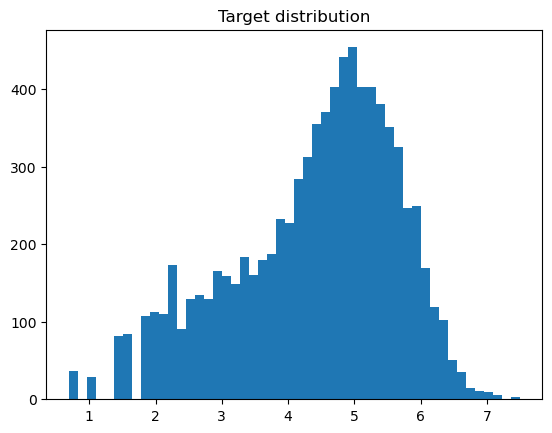

In [1384]:
plt.hist(y, bins=50)
plt.title("Target distribution")
plt.show()